In [83]:
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
df=pd.read_csv("data/demand_forecasting.csv")

In [85]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [86]:
df.columns = (
    df.columns
    .str.lower()              # alles klein schreiben
    .str.replace(" ", "_")    # Leerzeichen → Unterstrich
)

In [87]:
df.shape

(76000, 16)

In [88]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                76000 non-null  str    
 1   store_id            76000 non-null  str    
 2   product_id          76000 non-null  str    
 3   category            76000 non-null  str    
 4   region              76000 non-null  str    
 5   inventory_level     76000 non-null  int64  
 6   units_sold          76000 non-null  int64  
 7   units_ordered       76000 non-null  int64  
 8   price               76000 non-null  float64
 9   discount            76000 non-null  int64  
 10  weather_condition   76000 non-null  str    
 11  promotion           76000 non-null  int64  
 12  competitor_pricing  76000 non-null  float64
 13  seasonality         76000 non-null  str    
 14  epidemic            76000 non-null  int64  
 15  demand              76000 non-null  int64  
dtypes: float64(2), 

In [89]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekday"] = df["date"].dt.day_name()

In [90]:
df.isnull().sum()

date                  0
store_id              0
product_id            0
category              0
region                0
inventory_level       0
units_sold            0
units_ordered         0
price                 0
discount              0
weather_condition     0
promotion             0
competitor_pricing    0
seasonality           0
epidemic              0
demand                0
year                  0
month                 0
day                   0
weekday               0
dtype: int64

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,76000,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
inventory_level,76000.0,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
units_sold,76000.0,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
units_ordered,76000.0,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
price,76000.0,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
discount,76000.0,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781
promotion,76000.0,0.328947,0.0,0.0,0.0,1.0,1.0,0.469834
competitor_pricing,76000.0,69.454029,4.29,32.62,65.7,97.9325,261.22,40.943818
epidemic,76000.0,0.2,0.0,0.0,0.0,0.0,1.0,0.400003
demand,76000.0,104.317158,4.0,71.0,100.0,133.0,430.0,46.964801


* time span 2 years: 01.01.22 to 30.01.24
* target variable:
** mean 104, median 100, std 47, max 430 -> right skewed, no extrem outliers (max 4x mean)
** demand > unit sold (mean 104 vs 88) -> lost sales stocksouts
* there are articles with inventory level 0

In [93]:
df.describe(include="object").T

/var/folders/4c/4pm4bwz11292qrczgwq1dmfw0000gn/T/ipykernel_39350/1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
store_id,76000,5,S001,15200
product_id,76000,20,P0001,3800
category,76000,5,Groceries,30400
region,76000,4,North,30400
weather_condition,76000,4,Cloudy,24360
seasonality,76000,4,Winter,21000
weekday,76000,7,Saturday,10900


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                76000 non-null  datetime64[us]
 1   store_id            76000 non-null  str           
 2   product_id          76000 non-null  str           
 3   category            76000 non-null  str           
 4   region              76000 non-null  str           
 5   inventory_level     76000 non-null  int64         
 6   units_sold          76000 non-null  int64         
 7   units_ordered       76000 non-null  int64         
 8   price               76000 non-null  float64       
 9   discount            76000 non-null  int64         
 10  weather_condition   76000 non-null  str           
 11  promotion           76000 non-null  int64         
 12  competitor_pricing  76000 non-null  float64       
 13  seasonality         76000 non-null  str           
 14  e

In [95]:
df.columns

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'price', 'discount',
       'weather_condition', 'promotion', 'competitor_pricing', 'seasonality',
       'epidemic', 'demand', 'year', 'month', 'day', 'weekday'],
      dtype='str')

In [96]:
df.head(1)

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,promotion,competitor_pricing,seasonality,epidemic,demand,year,month,day,weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday


In [97]:
num_features = ['inventory_level', 'units_sold', 'units_ordered',
                'price', 'discount', 'competitor_pricing', 'demand', 'year', 'month', 'day']

cat_features = ['store_id', 'product_id', 'category', 'region','weather_condition', 'promotion','seasonality', 'epidemic']

date_features = ['date']

In [98]:
df.head()

,date,store_id,product_id,category,region,inventory_level,units_sold,units_ordered,price,discount,weather_condition,promotion,competitor_pricing,seasonality,epidemic,demand,year,month,day,weekday
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,Saturday
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,Saturday
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,Saturday
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,Saturday
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,Saturday


In [102]:
df.pivot_table(index = ["year","month"], columns= "category", values="units_sold",aggfunc="mean").round(2)

category    Clothing  Electronics  Furniture  Groceries    Toys
year month                                                     
2022 1        103.73        84.58      69.13     100.38   86.48
     2        109.79        91.71      74.32     106.21   88.51
     3         91.33        93.41      72.99     108.63  111.22
     4         92.53        81.56      64.10      97.04   85.66
     5         93.37        59.33      42.27      76.49   44.08
     6         89.62        89.21      69.24     121.36   82.52
     7         91.51        59.57      41.82      90.96   37.97
     8         91.48        94.17      73.73     126.71   87.65
     9         89.75        88.74      72.62     105.06   87.71
     10        87.57        87.31      71.25     102.70   85.74
     11        90.11        89.74      71.76     104.89   87.17
     12       105.88        93.41      71.01     106.07   88.40
2023 1        109.04        87.14      68.08     102.95   83.88
     2        105.99        52.47      33.99      71.21   28.70
     3         88.04        90.97      73.99     107.17  103.22
     4         88.70        65.69      46.26      83.66   58.48
     5         89.82        77.57      55.97      92.59   76.31
     6         89.14        92.97      70.65     126.08   88.81
     7         89.33        89.36      72.00     127.02   87.93
     8         90.77        92.19      73.90     126.66   88.15
     9         88.21        90.54      71.85     104.33   88.28
     10        93.33        65.11      49.76      84.69   50.64
     11        89.02        93.51      71.27     103.14   85.54
     12       106.54        86.58      65.92     100.44   77.68
2024 1        103.06        77.79      60.12      93.05   67.43

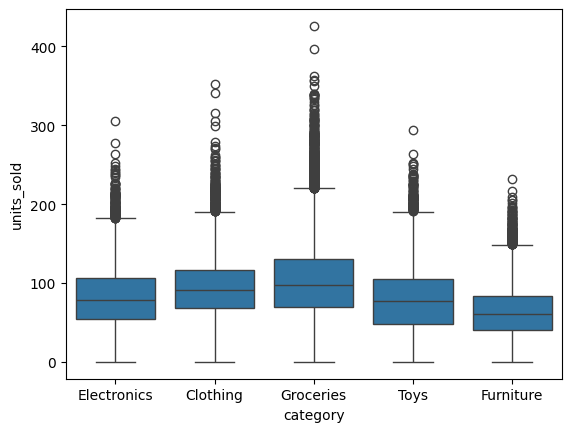

In [106]:
import seaborn as sns

sns.boxplot(data=df, x="category", y="units_sold")
plt.show()

In [80]:
df.groupby("category")["units_sold"].sum()

category
Clothing       1150873
Electronics     757335
Furniture       880654
Groceries      3127335
Toys            834679
Name: units_sold, dtype: int64

In [82]:
df.groupby("seasonality")["units_sold"].sum()

seasonality
Autumn    1610020
Spring    1535730
Summer    1761945
Winter    1843181
Name: units_sold, dtype: int64

In [24]:
df.groupby("Region")["Units Sold"].sum()

Region
East     1375613
North    2680946
South    1386126
West     1308191
Name: Units Sold, dtype: int64

In [ ]:
df_line = df.groupby(["year", "month"])["units_sold"].sum().reset_index()

In [ ]:
df_line["date"] = pd.to_datetime(df_line[["year", "month"]].assign(day=1))

In [35]:
df_line.head()

,year,month,Units Sold,Date
0,2022,1,283495,2022-01-01
1,2022,2,271108,2022-02-01
2,2022,3,303752,2022-03-01
3,2022,4,260812,2022-04-01
4,2022,5,205949,2022-05-01


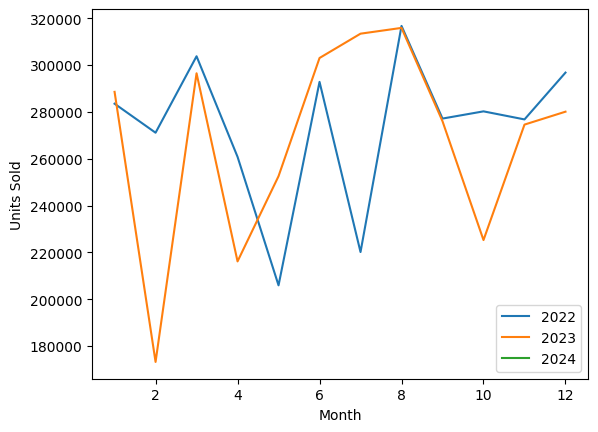

In [ ]:
for year in df_line["year"].unique():
    subset = df_line[df_line["year"] == year]
    plt.plot(subset["month"], subset["units_sold"], label=year)

plt.legend()
plt.xlabel("month")
plt.ylabel("units_sold")

plt.show()

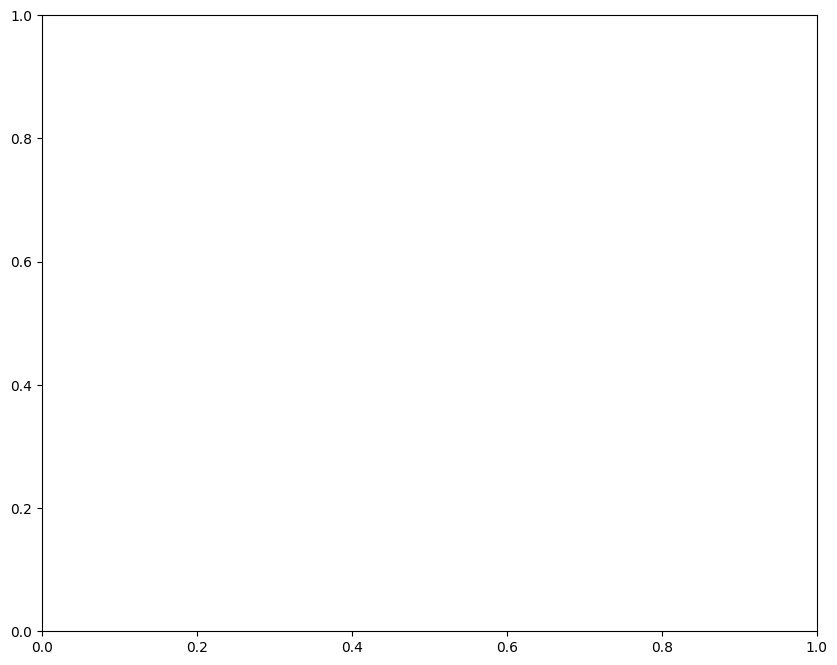

In [109]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ["inventory_level", "units_sold", "units_ordered",
            # "price", "discount", "competitor_pricing",
             "promotion", "epidemic", "demand"]
corr_matrix = df[corr_cols].corr()

In [68]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor



In [56]:
df = pd.read_csv("data/demand_forecasting.csv")
df.columns = (
    df.columns
    .str.lower()              # alles klein schreiben
    .str.replace(" ", "_")    # Leerzeichen → Unterstrich
)

In [58]:
features = [
    "price", "discount", "inventory_level","promotion", "competitor_pricing","category"
]

target = ["demand"]

In [59]:
X = df[features].copy()
y = df[target].copy()

In [64]:
label_encoders = {}

categorical_cols = X.select_dtypes(include="str").columns

In [63]:
categorical_cols

Index(['category'], dtype='str')

In [65]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [66]:
label_encoders

{'category': LabelEncoder()}

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)

In [69]:
xgb = XGBRegressor(objective="reg:squarederror",n_jobs=-1)

In [70]:
param_dict = {
    "n_estimators" : [200, 300, 500],
    "max_depth" : [3,5,7,9],
    "learning_rate" : [0.01,0.05,0.1]
}

In [72]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions=param_dict,
    n_iter = 20,
    scoring="neg_mean_absolute_error",
    cv = 3,
    n_jobs = -1
)

In [73]:
random_search.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged: